# Problema 4 - Gemelo Digital de un Sensor de Presión (10 Puntos)

Desarrollar un Gemelo Digital de un Sensor usando la tabla de Non-Linearity (%) vs Presión (Bar).

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1773432248.391713    9817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432248.392335    9817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773432248.464181    9817 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773432250.714171    9817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432250.714572    9817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
presion = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], dtype=np.float32)
non_linearity = np.array([0.00, 0.01, -0.02, -0.01, 0.02, 0.05, 0.09, 0.12, 0.06, -0.05, 0.00], dtype=np.float32)

In [3]:
presion_norm = presion / 1.0
nl_mean = np.mean(non_linearity)
nl_std = np.std(non_linearity)
nl_norm = (non_linearity - nl_mean) / nl_std

X = presion_norm.reshape(-1, 1)
y = nl_norm.reshape(-1, 1)

In [4]:
modelo = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='tanh', kernel_initializer='glorot_uniform'),
    layers.Dense(20, activation='tanh', kernel_initializer='glorot_uniform'),
    layers.Dense(1, activation='linear')
])

modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

E0000 00:00:1773432251.755322    9817 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
history = modelo.fit(X, y, epochs=3000, batch_size=11, verbose=0)
print("Entrenamiento completado")

Entrenamiento completado


In [6]:
y_pred_norm = modelo.predict(X, verbose=0)
y_pred = y_pred_norm.flatten() * nl_std + nl_mean

mse = np.mean((non_linearity - y_pred) ** 2)
mae = np.mean(np.abs(non_linearity - y_pred))
max_error = np.max(np.abs(non_linearity - y_pred))

print(f"MSE: {mse:.8f} %²")
print(f"MAE: {mae:.6f} %")
print(f"Error máximo absoluto: {max_error:.6f} %")
print()
print(f"{'Presión (Bar)':<15} {'Real (%)':<12} {'Predicho (%)':<15} {'Error (%)':<12}")
print('=' * 55)
for i in range(len(presion)):
    err = abs(non_linearity[i] - y_pred[i])
    print(f"{presion[i]:<15.1f} {non_linearity[i]:<12.2f} {y_pred[i]:<15.4f} {err:<12.6f}")

MSE: 0.00000008 %²
MAE: 0.000194 %
Error máximo absoluto: 0.000715 %

Presión (Bar)   Real (%)     Predicho (%)    Error (%)   
0.0             0.00         -0.0001         0.000121    
0.1             0.01         0.0099          0.000113    
0.2             -0.02        -0.0201         0.000064    
0.3             -0.01        -0.0101         0.000096    
0.4             0.02         0.0200          0.000026    
0.5             0.05         0.0500          0.000037    
0.6             0.09         0.0902          0.000155    
0.7             0.12         0.1203          0.000322    
0.8             0.06         0.0607          0.000715    
0.9             -0.05        -0.0496         0.000416    
1.0             0.00         0.0001          0.000073    


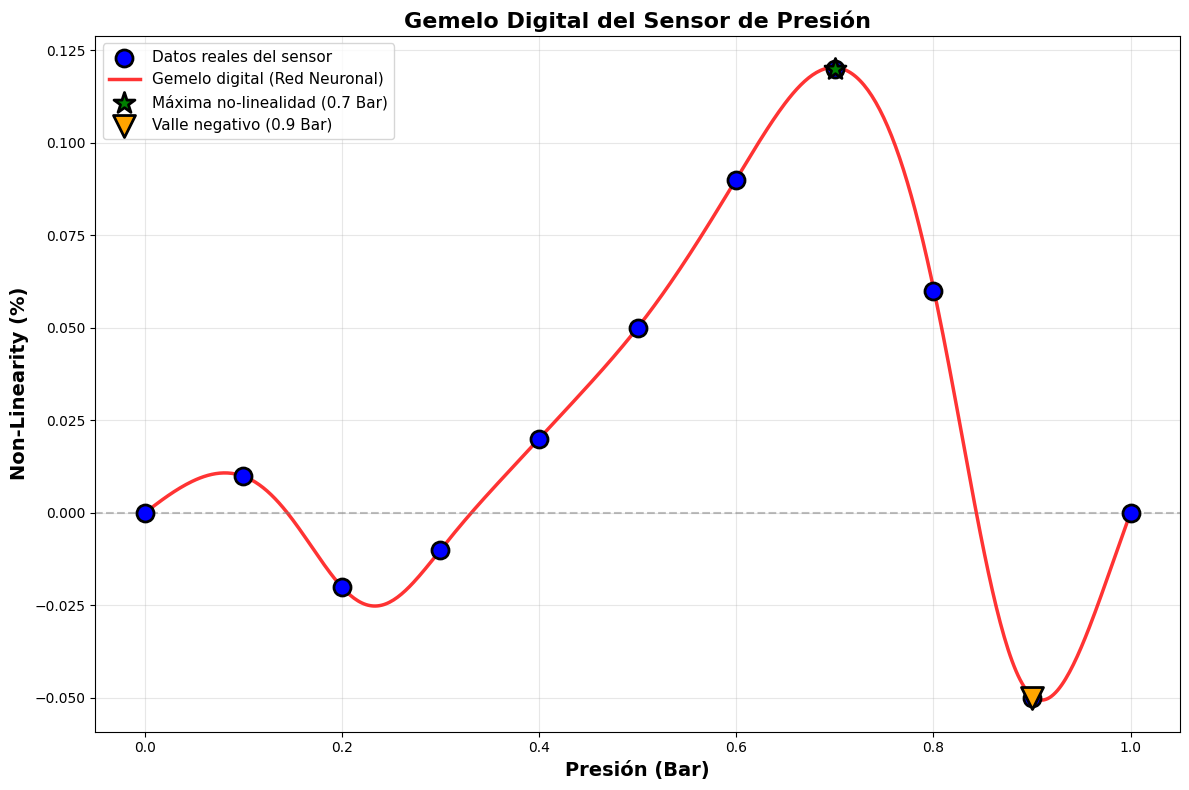

In [7]:
presion_densa = np.linspace(0, 1.0, 500)
presion_densa_norm = presion_densa / 1.0
nl_pred_norm = modelo.predict(presion_densa_norm.reshape(-1, 1), verbose=0)
nl_pred = nl_pred_norm.flatten() * nl_std + nl_mean

plt.figure(figsize=(12, 8))
plt.scatter(presion, non_linearity, color='blue', s=150, marker='o', edgecolors='black', linewidth=2, zorder=5, label='Datos reales del sensor')
plt.plot(presion_densa, nl_pred, 'r-', linewidth=2.5, alpha=0.8, label='Gemelo digital (Red Neuronal)')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
plt.scatter([0.7], [0.12], color='green', s=250, marker='*', edgecolors='black', linewidth=2, zorder=6, label='Máxima no-linealidad (0.7 Bar)')
plt.scatter([0.9], [-0.05], color='orange', s=250, marker='v', edgecolors='black', linewidth=2, zorder=6, label='Valle negativo (0.9 Bar)')
plt.xlabel('Presión (Bar)', fontsize=14, fontweight='bold')
plt.ylabel('Non-Linearity (%)', fontsize=14, fontweight='bold')
plt.title('Gemelo Digital del Sensor de Presión', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('problema_4_gemelo_digital.png', dpi=300, bbox_inches='tight')
plt.show()

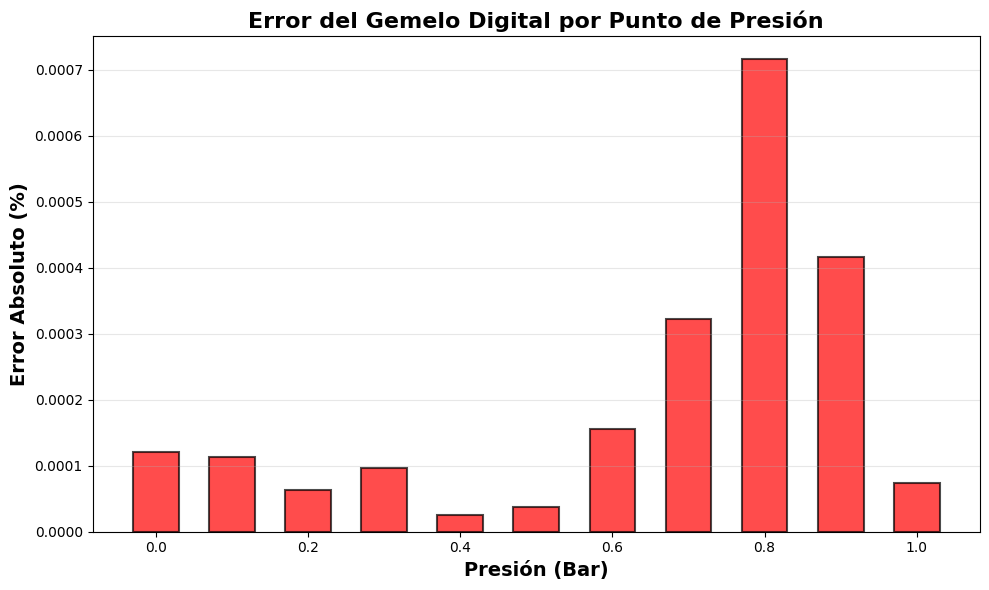

In [8]:
errores = np.abs(non_linearity - y_pred)

plt.figure(figsize=(10, 6))
plt.bar(presion, errores, width=0.06, color='red', edgecolor='black', linewidth=1.5, alpha=0.7)
plt.xlabel('Presión (Bar)', fontsize=14, fontweight='bold')
plt.ylabel('Error Absoluto (%)', fontsize=14, fontweight='bold')
plt.title('Error del Gemelo Digital por Punto de Presión', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('problema_4_error_barras.png', dpi=300, bbox_inches='tight')
plt.show()

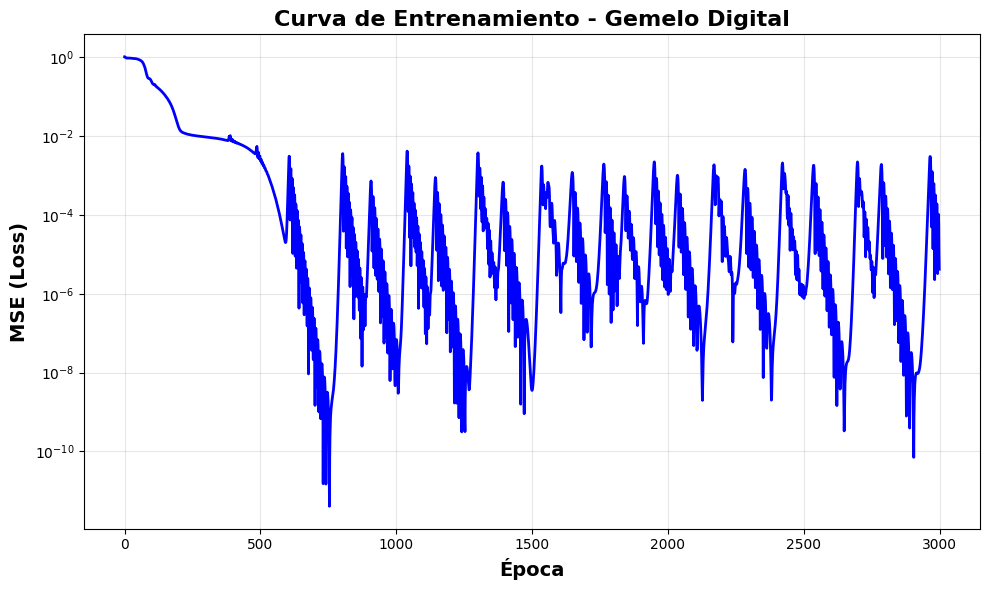

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], linewidth=2, color='blue')
plt.xlabel('Época', fontsize=14, fontweight='bold')
plt.ylabel('MSE (Loss)', fontsize=14, fontweight='bold')
plt.title('Curva de Entrenamiento - Gemelo Digital', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig('problema_4_loss.png', dpi=300, bbox_inches='tight')
plt.show()

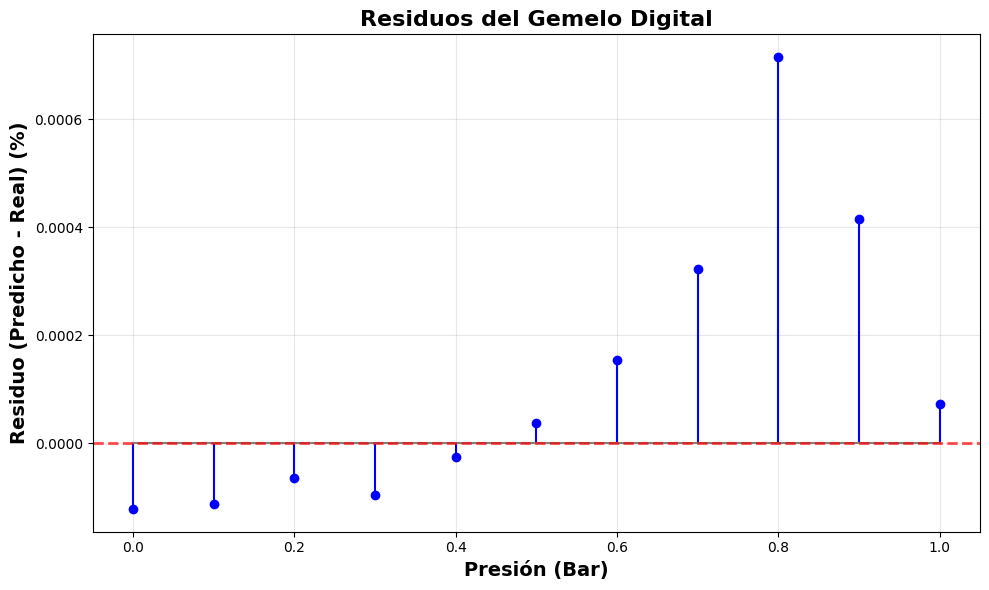

In [10]:
residuos = y_pred - non_linearity

plt.figure(figsize=(10, 6))
plt.stem(presion, residuos, linefmt='b-', markerfmt='bo', basefmt='gray')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Presión (Bar)', fontsize=14, fontweight='bold')
plt.ylabel('Residuo (Predicho - Real) (%)', fontsize=14, fontweight='bold')
plt.title('Residuos del Gemelo Digital', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problema_4_residuos.png', dpi=300, bbox_inches='tight')
plt.show()